In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv("sdss.csv")

## With feature 'i'

In [3]:
features = ['u', 'g', 'r', 'i', 'z']
X = data[features]
y = data['class']  

In [4]:
y = y.map({'GALAXY': 0, 'STAR': 1, 'QSO': 2})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) #might need to fiddle with this

In [5]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

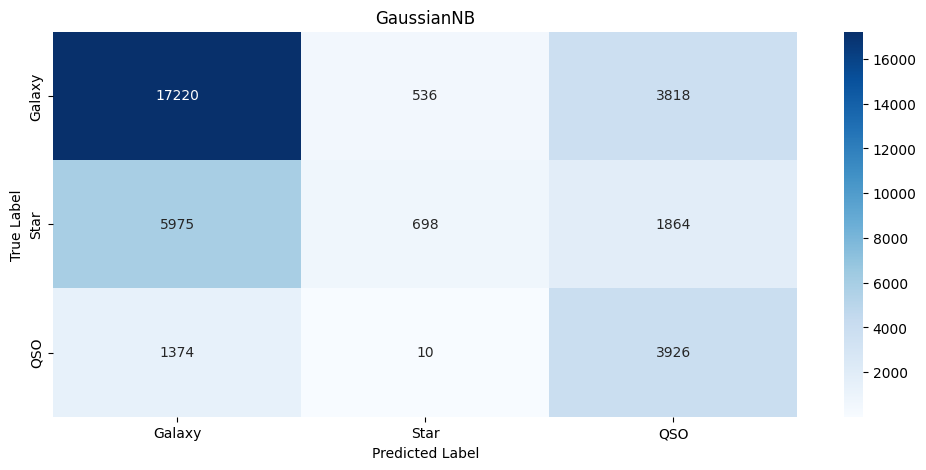

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))  
cm = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'], ax=ax)
ax.set_title("GaussianNB")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.show()


## Without feature 'i'

In [7]:
features = ['u', 'g', 'r', 'z']
X = data[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

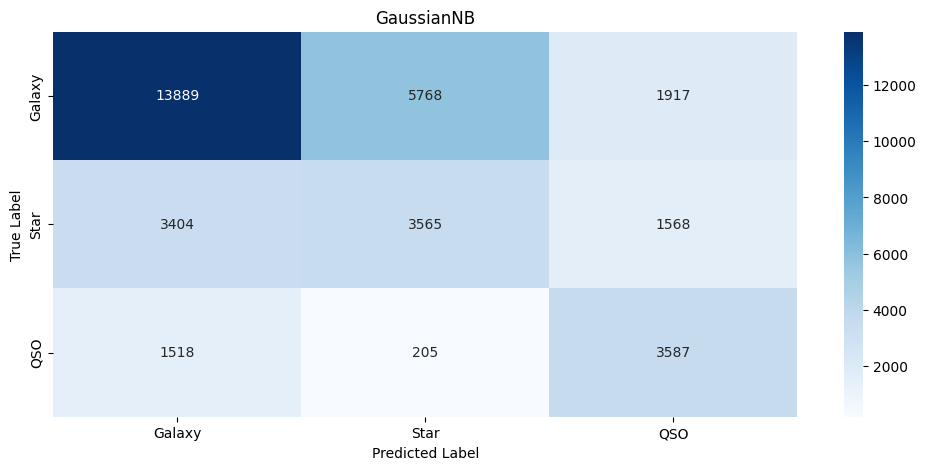

In [9]:
fig2, ax = plt.subplots(1, 1, figsize=(12, 5)) 
cm = confusion_matrix(y_test, y_pred_gnb)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'], ax=ax)
ax.set_title("GaussianNB")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.show()


comparing first and second confusion matrix:

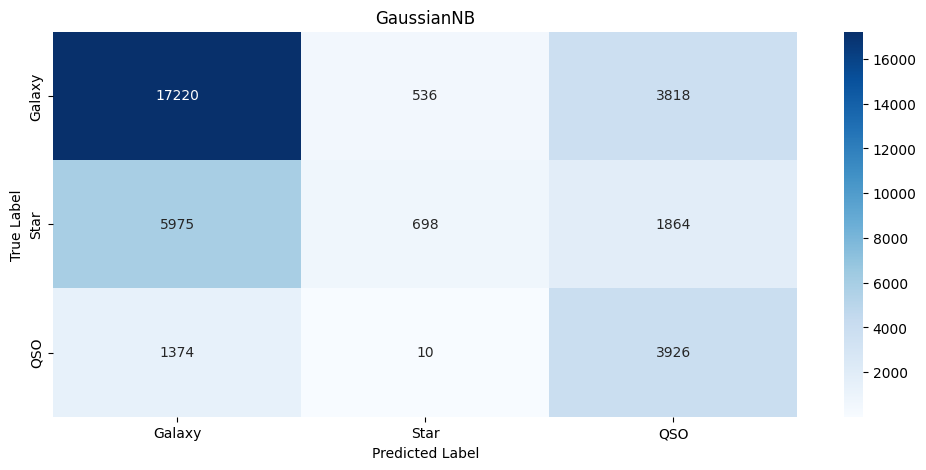

In [10]:
fig


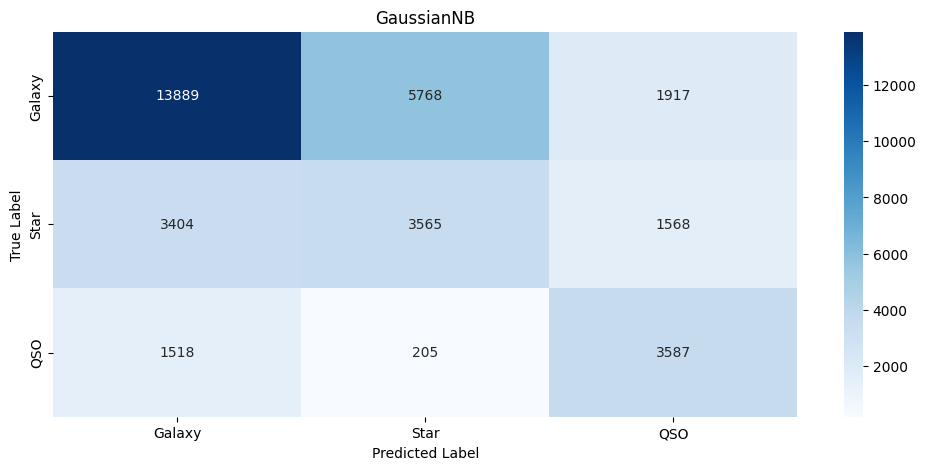

In [11]:
fig2

### Error margin has reduced in some ways and increased in others. Removing feature i is not yielding any good results. Let's try another approach.

## Section 3: Optimizing GaussianNB to Reduce Mislabeling

### Step 1: Remove Outliers

this removes outliers beyond 3 standard deviations

In [18]:
from scipy import stats

In [19]:
z_scores = np.abs(stats.zscore(X))
X_clean = X[(z_scores < 3).all(axis=1)]
y_clean = y[(z_scores < 3).all(axis=1)]


### Step 2: Standardise Features

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###  Step 3: Selecting 3 best features

In [24]:

from sklearn.feature_selection import SelectKBest, f_classif

In [25]:
selector = SelectKBest(f_classif, k=3)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)


###  Step 4: Tuning the Model

In [26]:
best_smoothing = None
best_accuracy = 0
for smoothing in np.logspace(-10, -5, 10):
    gnb = GaussianNB(var_smoothing=smoothing)
    gnb.fit(X_train_selected, y_train)
    acc = accuracy_score(y_test, gnb.predict(X_test_selected))
    if acc > best_accuracy:
        best_accuracy = acc
        best_smoothing = smoothing

In [27]:
print(f"Best var_smoothing: {best_smoothing}, Accuracy: {best_accuracy}")

Best var_smoothing: 1e-10, Accuracy: 0.6282995962846899


In [28]:
gnb_optimized = GaussianNB(var_smoothing=best_smoothing)
gnb_optimized.fit(X_train_selected, y_train)
y_pred_optimized = gnb_optimized.predict(X_test_selected)

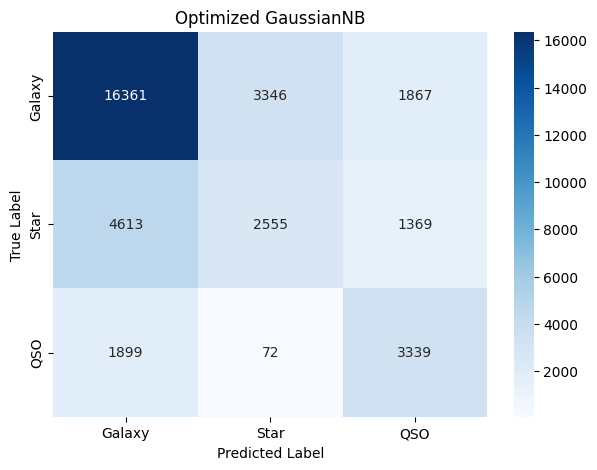

In [29]:
fig3, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'], ax=ax)
ax.set_title("Optimized GaussianNB")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.show()

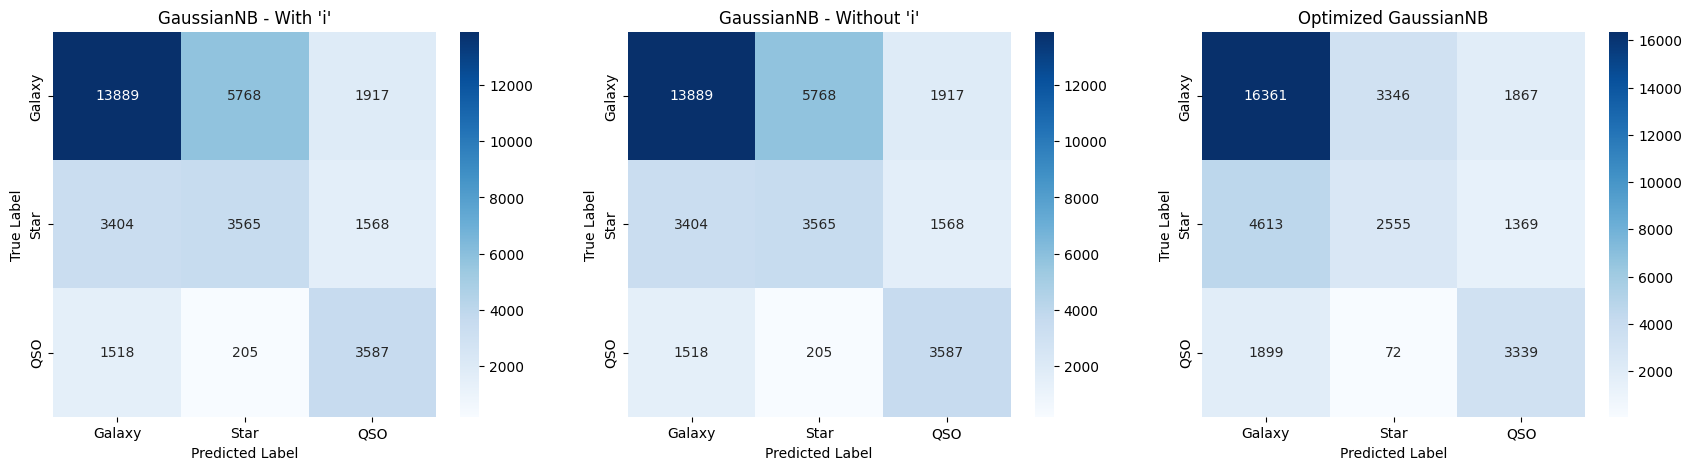

In [30]:
fig4, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, cm, title in zip(axes, [confusion_matrix(y_test, y_pred_gnb), confusion_matrix(y_test, y_pred_gnb), cm],
                         ["GaussianNB - With 'i'", "GaussianNB - Without 'i'", "Optimized GaussianNB"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Galaxy', 'Star', 'QSO'], yticklabels=['Galaxy', 'Star', 'QSO'], ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
plt.show()
